# MP150 real-time LSTM prediction with post-hoc accuracy and delay analysis (100MS Stride)

This notebook loads the saved LSTM checkpoint from the cleaned trainer, streams one channel from the MP150, keeps a causal sliding buffer, and prints a real-time binary prediction:

```text
0 = Idle
1 = Beta
```

The notebook automatically uses the checkpoint's saved preprocessing metadata:

- `feature_mode`: `raw_signal` or `fft_bandpower`
- `window_samples`
- `stride_samples`
- `normalizer_mean`
- `normalizer_std`
- `fs`

The MP150 acquisition interface follows the pattern:

```python
mp = MP150(samplerate=samplerate, channels=channels)
chunk = mp.get_chunk(duration_sec)   # expected shape: (samples, channels)
```

At the end, the notebook saves the recorded MP150 signal, relabels that signal using the same sample-level causal rolling-RMS threshold logic as the synthetic-signal relabeling notebook, computes prediction accuracy, estimates transition delay, and plots raw signal, true labels, predicted labels, and `P(1 Beta)` on one shared axis.


In [ ]:
# Optional Google Drive mount for Colab.
from pathlib import Path

try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
    else:
        print('Google Drive already mounted.')
except Exception as exc:
    print(f'Google Drive mount skipped: {exc}')


Google Drive mount skipped: No module named 'google'


## User-editable settings

Most runs only need `CHECKPOINT_PATH`, `CHANNELS`, and `RUN_DURATION_SEC` changed.

`CHECKPOINT_PATH` defaults to the raw-signal model because that is the most direct online mode. If you trained/saved the FFT-bandpower model instead, point `CHECKPOINT_PATH` to `lstm_fft_bandpower_checkpoint.pt`. The code will detect the feature mode from the checkpoint.

In [ ]:
import csv
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn


# =============================================================================
# CHECKPOINT PATH
# =============================================================================

CHECKPOINT_PATH = Path(
    '/lstm_raw_signal_checkpoint_100ms_stride.pt'
)

ALT_CHECKPOINT_PATHS = [
    Path('/content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/Drive Code/sg_results_clean_lstm/lstm_fft_bandpower_checkpoint.pt'),
    Path('/content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/sg_results_clean_lstm/lstm_raw_signal_checkpoint.pt'),
    Path('/content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/sg_results_clean_lstm/lstm_fft_bandpower_checkpoint.pt'),
]

# =============================================================================
# MP150 SETTINGS
# =============================================================================

# Hardware channels passed to MP150. The uploaded notebook used channels=[1].
CHANNELS = [1]

# Which column to use from the returned chunk. With channels=[1], this should stay 0.
MP150_CHANNEL_INDEX = 0

# How much data to request per MP150 call. It can be smaller than the model stride;
# predictions are emitted whenever enough new samples have accumulated.
CHUNK_SEC = 0.10

# Set to None to run until KeyboardInterrupt. Use a finite value for quick tests.
RUN_DURATION_SEC = 30.0

# Leave as None to use checkpoint['fs']; override only if you know what you are doing.
OVERRIDE_SAMPLERATE = None


# =============================================================================
# OPTIONAL SIGNAL CALIBRATION
# =============================================================================

# These are applied to the incoming MP150 signal before inference:
#     x_online = x_raw * SIGNAL_SCALE + SIGNAL_OFFSET
#     if INVERT_SIGNAL: x_online = -x_online
# Keep these unchanged if the MP150 signal units match the training data units.
SIGNAL_SCALE = 1.0
SIGNAL_OFFSET = 0.0
INVERT_SIGNAL = False


# =============================================================================
# OUTPUT LOGGING
# =============================================================================

# Leave OUTPUT_DIR as None to save next to the resolved checkpoint path.
# Set it to a Path if you want a specific output folder.
OUTPUT_DIR = None
PREDICTION_CSV_NAME = 'mpy150_realtime_predictions.csv'
RECORDED_SIGNAL_NPZ_NAME = 'mpy150_recorded_signal.npz'
OVERLAY_PNG_NAME = 'mpy150_prediction_overlay.png'
EVALUATED_PREDICTION_CSV_NAME = 'mpy150_realtime_predictions_evaluated.csv'
TRUE_LABELS_NPZ_NAME = 'mpy150_true_labels.npz'
DELAY_METRICS_CSV_NAME = 'mpy150_prediction_delay_by_transition.csv'
EVALUATION_SUMMARY_CSV_NAME = 'mpy150_prediction_accuracy_delay_summary.csv'
PRINT_EVERY_PREDICTION = True

# Final overlay plot options.
# Use 'raw_signal' to plot the unmodified MP150 channel, or 'model_input_signal'
# to plot the calibrated/inverted signal that was passed to the model.
PLOT_SIGNAL_KEY = 'raw_signal'
PLOT_MAX_DURATION_SEC = None  # Set to a number, e.g. 30, to zoom the final plot.

# Prediction plotting layout. Kept for compatibility with previous versions; this notebook
# plots model outputs literally as 0/1 and probability values in [0, 1] on the shared axis.
PLOT_LAYOUT = 'literal_shared_axis'
PLOT_SHOW_PREDICTED_BETA_SPANS = True
PLOT_SIGNAL_BAND_FRACTION = 1.00  # Used only by the legacy 'signal_band' layout.
PLOT_SIGNAL_PERCENTILES = (1.0, 99.0)

# =============================================================================
# TRUE-LABELING AND EVALUATION SETTINGS
# =============================================================================

# Use the same causal rolling-RMS threshold logic as sgv4_relabel_fixed_threshold.ipynb.
TRUE_LABEL_METHOD = 'causal_rolling_rms_threshold'
TRUE_LABEL_ROLLING_RMS_SEC = 0.025
TRUE_LABEL_THRESHOLD = 0.25
TRUE_LABEL_HIGH_LABEL = 0  # Idle / high amplitude
TRUE_LABEL_LOW_LABEL = 1   # Beta / low amplitude

# Which recorded signal to relabel after acquisition:
#   'model_input_signal' -> recommended; uses the calibrated/inverted signal that was passed to the model.
#   'raw_signal'         -> uses the raw MP150 channel before SIGNAL_SCALE/OFFSET/INVERT_SIGNAL.
TRUE_LABEL_SIGNAL_KEY = 'model_input_signal'

# How to map sample-level true labels onto prediction windows.
# The cleaned trainer used endpoint labels by default, so endpoint is the online-aligned default.
TRUE_LABEL_WINDOW_MODE = 'endpoint'  # options: 'endpoint' or 'majority'

# Transition-delay analysis settings.
# A true transition is counted as detected when the first post-transition prediction equals the new true state.
DELAY_MATCH_MAX_SEC = 5.0
DELAY_IGNORE_INITIAL_SEC = 0.0

# Final plot options for relabeled ground truth.
PLOT_SHOW_TRUE_LABEL = True
PLOT_SHOW_TRUE_LABEL_SIGNAL = False


# =============================================================================
# MP150 MODULE SEARCH PATHS
# =============================================================================

# The notebook will append any existing paths here before importing mpy150_chunk.MP150.
MPY150_MODULE_DIRS = [
    Path.cwd(),
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cpu


## Saved LSTM architecture and checkpoint loader

This architecture matches the cleaned training notebook checkpoint format.

In [ ]:
class LSTMClassifier(nn.Module):
    """Minimal LSTM classifier for binary Idle/Beta classification."""
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, num_classes: int = 2, dropout: float = 0.0):
        super().__init__()
        effective_dropout = float(dropout) if int(num_layers) > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=int(input_size),
            hidden_size=int(hidden_size),
            num_layers=int(num_layers),
            batch_first=True,
            dropout=effective_dropout,
        )
        self.fc = nn.Linear(int(hidden_size), int(num_classes))

    def forward(self, x):
        # x shape: (batch, time, features)
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)


def _unique_paths(paths):
    seen = set()
    out = []
    for path in paths:
        path = Path(path)
        key = str(path)
        if key not in seen:
            seen.add(key)
            out.append(path)
    return out


def resolve_checkpoint_path(primary_path, alt_paths=None):
    """Find the saved .pt checkpoint across Drive/current-directory/local fallbacks."""
    primary_path = Path(primary_path)
    alt_paths = list(alt_paths or [])

    candidates = [primary_path]
    candidates.extend(alt_paths)

    # Local fallbacks with the same filenames.
    filenames = [primary_path.name, 'lstm_raw_signal_checkpoint.pt', 'lstm_fft_bandpower_checkpoint.pt']
    for name in filenames:
        candidates.extend([
            Path.cwd() / name,
            Path('/mnt/data') / name,
        ])

    candidates = _unique_paths(candidates)
    for path in candidates:
        if path.exists():
            return path

    msg = 'Could not find a saved LSTM checkpoint. Checked:\n' + '\n'.join(f'  - {p}' for p in candidates)
    raise FileNotFoundError(msg)


def load_saved_model(checkpoint_path, device=None):
    """Load the saved checkpoint and recreate the LSTM model."""
    checkpoint_path = Path(checkpoint_path)
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)

    if 'model_config' not in checkpoint or 'model_state_dict' not in checkpoint:
        raise KeyError('Checkpoint must contain model_config and model_state_dict.')

    model_cfg = checkpoint['model_config']
    model = LSTMClassifier(**model_cfg)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    return model, checkpoint


def checkpoint_feature_mode(checkpoint):
    return str(checkpoint.get('feature_mode', checkpoint.get('config', {}).get('feature_mode', 'raw_signal')))


def checkpoint_fs(checkpoint):
    if 'fs' not in checkpoint:
        raise KeyError('Checkpoint is missing fs.')
    return int(checkpoint['fs'])


def checkpoint_window_samples(checkpoint):
    if 'window_samples' in checkpoint:
        return int(checkpoint['window_samples'])
    cfg = checkpoint.get('config', {})
    return int(round(float(cfg.get('window_sec', 1.0)) * checkpoint_fs(checkpoint)))


def checkpoint_stride_samples(checkpoint):
    if 'stride_samples' in checkpoint:
        return int(checkpoint['stride_samples'])
    cfg = checkpoint.get('config', {})
    return int(round(float(cfg.get('stride_sec', 0.25)) * checkpoint_fs(checkpoint)))


def checkpoint_bandpower_hz(checkpoint):
    band = checkpoint.get('bandpower_hz', checkpoint.get('config', {}).get('bandpower_hz', (18.0, 22.0)))
    return tuple(float(x) for x in band)


checkpoint_path = resolve_checkpoint_path(CHECKPOINT_PATH, ALT_CHECKPOINT_PATHS)
model, checkpoint = load_saved_model(checkpoint_path, DEVICE)

if OUTPUT_DIR is None:
    OUTPUT_DIR = checkpoint_path.parent / 'mp150_online_predictions'
else:
    OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_CSV = OUTPUT_DIR / PREDICTION_CSV_NAME
RECORDED_SIGNAL_NPZ = OUTPUT_DIR / RECORDED_SIGNAL_NPZ_NAME
OVERLAY_PNG = OUTPUT_DIR / OVERLAY_PNG_NAME
EVALUATED_PREDICTION_CSV = OUTPUT_DIR / EVALUATED_PREDICTION_CSV_NAME
TRUE_LABELS_NPZ = OUTPUT_DIR / TRUE_LABELS_NPZ_NAME
DELAY_METRICS_CSV = OUTPUT_DIR / DELAY_METRICS_CSV_NAME
EVALUATION_SUMMARY_CSV = OUTPUT_DIR / EVALUATION_SUMMARY_CSV_NAME

print(f'Loaded checkpoint: {checkpoint_path}')
print(f"feature_mode:    {checkpoint_feature_mode(checkpoint)}")
print(f"fs:              {checkpoint_fs(checkpoint)} Hz")
print(f"window_samples:  {checkpoint_window_samples(checkpoint)}")
print(f"stride_samples:  {checkpoint_stride_samples(checkpoint)}")
print(f"bandpower_hz:    {checkpoint_bandpower_hz(checkpoint)}")
print(f"model_config:    {checkpoint['model_config']}")
print(f'prediction log:  {PREDICTION_CSV}')
print(f'recorded signal: {RECORDED_SIGNAL_NPZ}')
print(f'overlay plot:    {OVERLAY_PNG}')
print(f'evaluated preds: {EVALUATED_PREDICTION_CSV}')
print(f'true labels:     {TRUE_LABELS_NPZ}')
print(f'delay metrics:   {DELAY_METRICS_CSV}')
print(f'eval summary:    {EVALUATION_SUMMARY_CSV}')


Loaded checkpoint: d:\experiment\MPy150\lstm_raw_signal_checkpoint_100ms_stride.pt
feature_mode:    raw_signal
fs:              200 Hz
window_samples:  200
stride_samples:  20
bandpower_hz:    (18.0, 22.0)
model_config:    {'input_size': 1, 'hidden_size': 4, 'num_layers': 1, 'num_classes': 2, 'dropout': 0.0}
prediction log:  d:\experiment\MPy150\mp150_online_predictions\mpy150_realtime_predictions.csv
recorded signal: d:\experiment\MPy150\mp150_online_predictions\mpy150_recorded_signal.npz
overlay plot:    d:\experiment\MPy150\mp150_online_predictions\mpy150_prediction_overlay.png
evaluated preds: d:\experiment\MPy150\mp150_online_predictions\mpy150_realtime_predictions_evaluated.csv
true labels:     d:\experiment\MPy150\mp150_online_predictions\mpy150_true_labels.npz
delay metrics:   d:\experiment\MPy150\mp150_online_predictions\mpy150_prediction_delay_by_transition.csv
eval summary:    d:\experiment\MPy150\mp150_online_predictions\mpy150_prediction_accuracy_delay_summary.csv


## Preprocessing and one-window prediction

These functions reproduce the training-time preprocessing from the checkpoint.

In [ ]:
def fft_log_bandpower_1d(x, fs: int, band=(18.0, 22.0), eps=1e-12) -> float:
    """Return log10 FFT band power for one 1D window."""
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) < 2:
        raise ValueError('FFT band power requires at least two samples per window.')

    x = x - np.mean(x)
    taper = np.hanning(len(x)).astype(np.float32)
    xw = x * taper

    freqs = np.fft.rfftfreq(len(xw), d=1.0 / int(fs))
    fft_vals = np.fft.rfft(xw)
    power = np.abs(fft_vals) ** 2

    low, high = float(band[0]), float(band[1])
    mask = (freqs >= low) & (freqs <= high)
    if not np.any(mask):
        raise ValueError(f'No FFT bins inside band={band} for fs={fs} and window length={len(x)}.')

    return float(np.log10(np.sum(power[mask]) + eps))


def build_single_window_features(raw_window, checkpoint):
    """Create a single LSTM input window with shape (1, time, features)."""
    raw_window = np.asarray(raw_window, dtype=np.float32).reshape(-1)
    fs = checkpoint_fs(checkpoint)
    win = checkpoint_window_samples(checkpoint)
    feature_mode = checkpoint_feature_mode(checkpoint)

    if len(raw_window) != win:
        raise ValueError(f'Expected raw_window length {win}, got {len(raw_window)}.')

    if feature_mode == 'raw_signal':
        # Training shape per window: (window_samples, 1)
        X = raw_window[None, :, None]
    elif feature_mode == 'fft_bandpower':
        # Training shape per window: (1, 1)
        bp = fft_log_bandpower_1d(raw_window, fs=fs, band=checkpoint_bandpower_hz(checkpoint))
        X = np.asarray([[[bp]]], dtype=np.float32)
    else:
        raise ValueError(f'Unknown feature_mode in checkpoint: {feature_mode!r}')

    return X.astype(np.float32)


def apply_checkpoint_normalizer(X, checkpoint):
    """Apply normalizer_mean/normalizer_std saved in the checkpoint."""
    if 'normalizer_mean' not in checkpoint or 'normalizer_std' not in checkpoint:
        raise KeyError('Checkpoint must contain normalizer_mean and normalizer_std.')

    mean = np.asarray(checkpoint['normalizer_mean'], dtype=np.float32)
    std = np.asarray(checkpoint['normalizer_std'], dtype=np.float32)
    std = np.where(std < 1e-6, 1.0, std)
    return ((X - mean) / std).astype(np.float32)


@torch.no_grad()
def predict_one_window(model, checkpoint, raw_window, device=None):
    """Return one prediction dict for one raw causal window."""
    if device is None:
        device = next(model.parameters()).device

    X = build_single_window_features(raw_window, checkpoint)
    X_norm = apply_checkpoint_normalizer(X, checkpoint)

    xb = torch.as_tensor(X_norm, dtype=torch.float32, device=device)
    logits = model(xb)
    probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
    pred = int(np.argmax(probs))

    return {
        'pred_label': pred,
        'prob_idle': float(probs[0]),
        'prob_beta': float(probs[1]),
    }


def preprocess_online_signal(x):
    """Apply optional online calibration to an incoming MP150 1D signal chunk."""
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    x = x * float(SIGNAL_SCALE) + float(SIGNAL_OFFSET)
    if bool(INVERT_SIGNAL):
        x = -x
    return x.astype(np.float32)


## MP150 helpers

In [ ]:
def import_mp150_class(module_dirs=None):
    """Import MP150 from mpy150_chunk.py, adding likely module directories first."""
    module_dirs = list(module_dirs or [])
    for module_dir in module_dirs:
        module_dir = Path(module_dir)
        if module_dir.exists():
            module_dir_str = str(module_dir)
            if module_dir_str not in sys.path:
                sys.path.insert(0, module_dir_str)

    try:
        from mpy150_chunk import MP150
    except ModuleNotFoundError as exc:
        searched = '\n'.join(f'  - {Path(p)}' for p in module_dirs)
        raise ModuleNotFoundError(
            'Could not import MP150 from mpy150_chunk.py.\n'
            'Put mpy150_chunk.py in the notebook directory, or add its folder to MPY150_MODULE_DIRS.\n'
            f'Searched module directories:\n{searched}'
        ) from exc

    return MP150


def extract_single_channel_from_chunk(chunk, channel_index=0):
    """Return one channel as a 1D float32 vector from an MP150 chunk.

    The uploaded MP150 notebook used chunks with shape (samples, channels).
    This helper also tolerates a transposed (channels, samples) array.
    """
    arr = np.asarray(chunk, dtype=np.float32)

    if arr.ndim == 1:
        return arr.astype(np.float32)

    if arr.ndim != 2:
        raise ValueError(f'Expected chunk to be 1D or 2D, got shape {arr.shape}.')

    channel_index = int(channel_index)

    # Expected/common case: (samples, channels).
    if arr.shape[1] <= arr.shape[0]:
        if channel_index >= arr.shape[1]:
            raise IndexError(f'channel_index={channel_index} but chunk has only {arr.shape[1]} columns/channels.')
        return arr[:, channel_index].astype(np.float32)

    # Fallback case: (channels, samples).
    if channel_index >= arr.shape[0]:
        raise IndexError(f'channel_index={channel_index} but chunk has only {arr.shape[0]} rows/channels.')
    return arr[channel_index, :].astype(np.float32)


## Real-time MP150 inference loop

The first prediction is emitted after one full model window has been collected. After that, a new prediction is emitted every checkpoint stride.

In [ ]:
def _write_prediction_csv_header(csv_path):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                'wall_time_sec',
                'end_sample',
                'end_time_sec',
                'pred_label',
                'prob_idle',
                'prob_beta',
                'feature_mode',
                'window_samples',
                'stride_samples',
            ],
        )
        writer.writeheader()


def _append_prediction_csv(csv_path, row):
    csv_path = Path(csv_path)
    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        writer.writerow(row)


def _save_recorded_signal_npz(
    output_npz,
    raw_signal,
    model_input_signal,
    samplerate,
    channels,
    channel_index,
    checkpoint_path=None,
):
    """Save the actual MP150 trace and the calibrated trace used for inference."""
    output_npz = Path(output_npz)
    output_npz.parent.mkdir(parents=True, exist_ok=True)

    raw_signal = np.asarray(raw_signal, dtype=np.float32).reshape(-1)
    model_input_signal = np.asarray(model_input_signal, dtype=np.float32).reshape(-1)
    samplerate = int(samplerate)
    time_sec = np.arange(len(raw_signal), dtype=np.float64) / float(samplerate)

    np.savez(
        output_npz,
        raw_signal=raw_signal,
        model_input_signal=model_input_signal,
        time_sec=time_sec,
        samplerate=np.array(samplerate, dtype=np.int64),
        channels=np.asarray(list(channels), dtype=np.int64),
        channel_index=np.array(int(channel_index), dtype=np.int64),
        signal_scale=np.array(float(SIGNAL_SCALE), dtype=np.float64),
        signal_offset=np.array(float(SIGNAL_OFFSET), dtype=np.float64),
        invert_signal=np.array(bool(INVERT_SIGNAL)),
        checkpoint_path=np.array(str(checkpoint_path) if checkpoint_path is not None else ''),
        label_convention=np.array('0=Idle, 1=Beta'),
    )
    return output_npz


def run_mp150_realtime_inference(
    model,
    checkpoint,
    channels=(1,),
    channel_index=0,
    chunk_sec=0.10,
    run_duration_sec=120.0,
    samplerate=None,
    output_csv=None,
    output_recorded_npz=None,
    print_every_prediction=True,
):
    """Stream MP150 chunks, record the signal, and emit real-time 0/1 LSTM predictions.

    Parameters
    ----------
    model, checkpoint
        Loaded LSTM model and checkpoint dictionary.
    channels
        Hardware channel list passed into MP150, for example [1].
    channel_index
        Index inside the returned MP150 chunk to use. With channels=[1], use 0.
    chunk_sec
        Duration passed to mp.get_chunk(chunk_sec).
    run_duration_sec
        Finite duration in seconds, or None to run until KeyboardInterrupt.
    samplerate
        MP150 samplerate. If None, uses checkpoint['fs'].
    output_csv
        Prediction log path. If None, predictions are not written to disk.
    output_recorded_npz
        Recorded signal path. If None, the signal is returned but not saved.
    print_every_prediction
        If True, print one line per emitted prediction.
    """
    MP150 = import_mp150_class(MPY150_MODULE_DIRS)

    fs_expected = checkpoint_fs(checkpoint)
    samplerate = fs_expected if samplerate is None else int(samplerate)
    if samplerate != fs_expected:
        raise ValueError(
            f'Samplerate mismatch: MP150 samplerate={samplerate}, but checkpoint expects fs={fs_expected}. '
            'Use the same samplerate as training or retrain/resample explicitly.'
        )

    window_samples = checkpoint_window_samples(checkpoint)
    stride_samples = checkpoint_stride_samples(checkpoint)
    feature_mode = checkpoint_feature_mode(checkpoint)

    if stride_samples <= 0 or window_samples <= 0:
        raise ValueError('window_samples and stride_samples must be positive.')

    if output_csv is not None:
        _write_prediction_csv_header(output_csv)
        print(f'Writing prediction log to: {output_csv}')

    mp = MP150(samplerate=samplerate, channels=list(channels))
    print(f'Initialized MP150: channels={list(channels)} @ {samplerate} Hz')
    print(f'Model mode={feature_mode}, window={window_samples} samples ({window_samples / samplerate:.3f}s), stride={stride_samples} samples ({stride_samples / samplerate:.3f}s)')
    print('Streaming predictions. Stop with KeyboardInterrupt if run_duration_sec=None.')

    session_start_wall = time.time()
    total_samples_seen = 0
    next_prediction_end = window_samples
    buffer_start_sample = 0
    buffer = np.empty(0, dtype=np.float32)
    prediction_rows = []

    # Store both the true acquired channel and the calibrated/inverted signal used by the model.
    raw_signal_chunks = []
    model_input_signal_chunks = []

    try:
        while True:
            elapsed_wall = time.time() - session_start_wall
            if run_duration_sec is not None and elapsed_wall >= float(run_duration_sec):
                break

            chunk = mp.get_chunk(float(chunk_sec))
            x_raw = extract_single_channel_from_chunk(chunk, channel_index=channel_index)
            x_model = preprocess_online_signal(x_raw)
            if len(x_model) == 0:
                continue

            raw_signal_chunks.append(np.asarray(x_raw, dtype=np.float32).copy())
            model_input_signal_chunks.append(np.asarray(x_model, dtype=np.float32).copy())

            buffer = np.concatenate([buffer, x_model])
            total_samples_seen += int(len(x_model))

            while total_samples_seen >= next_prediction_end:
                start_sample = next_prediction_end - window_samples
                rel_start = start_sample - buffer_start_sample
                rel_end = next_prediction_end - buffer_start_sample

                if rel_start < 0 or rel_end > len(buffer):
                    raise RuntimeError(
                        'Internal buffer alignment error. '
                        f'rel_start={rel_start}, rel_end={rel_end}, len(buffer)={len(buffer)}'
                    )

                raw_window = buffer[rel_start:rel_end]
                pred = predict_one_window(model, checkpoint, raw_window, device=DEVICE)

                row = {
                    'wall_time_sec': float(time.time() - session_start_wall),
                    'end_sample': int(next_prediction_end),
                    'end_time_sec': float(next_prediction_end / samplerate),
                    'pred_label': int(pred['pred_label']),
                    'prob_idle': float(pred['prob_idle']),
                    'prob_beta': float(pred['prob_beta']),
                    'feature_mode': feature_mode,
                    'window_samples': int(window_samples),
                    'stride_samples': int(stride_samples),
                }
                prediction_rows.append(row)

                if output_csv is not None:
                    _append_prediction_csv(output_csv, row)

                if print_every_prediction:
                    print(
                        f"t={row['end_time_sec']:8.3f}s | "
                        f"prediction={row['pred_label']} | "
                        f"P(0)={row['prob_idle']:.3f} | "
                        f"P(1)={row['prob_beta']:.3f}",
                        flush=True,
                    )

                next_prediction_end += stride_samples

            # Keep only samples that may be needed for the next prediction window.
            min_needed_sample = max(0, next_prediction_end - window_samples)
            trim_count = min_needed_sample - buffer_start_sample
            if trim_count > 0:
                buffer = buffer[trim_count:]
                buffer_start_sample += trim_count

    except KeyboardInterrupt:
        print('Interrupted by user.')
    finally:
        try:
            mp.close()
            print('MP150 connection closed.')
        except Exception as exc:
            print(f'MP150 close skipped/failed: {exc}')

    if raw_signal_chunks:
        recorded_raw_signal = np.concatenate(raw_signal_chunks).astype(np.float32)
        recorded_model_input_signal = np.concatenate(model_input_signal_chunks).astype(np.float32)
    else:
        recorded_raw_signal = np.empty(0, dtype=np.float32)
        recorded_model_input_signal = np.empty(0, dtype=np.float32)

    if output_recorded_npz is not None:
        saved_npz = _save_recorded_signal_npz(
            output_npz=output_recorded_npz,
            raw_signal=recorded_raw_signal,
            model_input_signal=recorded_model_input_signal,
            samplerate=samplerate,
            channels=channels,
            channel_index=channel_index,
            checkpoint_path=checkpoint_path if 'checkpoint_path' in globals() else None,
        )
        print(f'Saved recorded signal to: {saved_npz}')

    predictions_df = pd.DataFrame(prediction_rows)
    predictions_df.attrs['raw_signal'] = recorded_raw_signal
    predictions_df.attrs['model_input_signal'] = recorded_model_input_signal
    predictions_df.attrs['samplerate'] = int(samplerate)

    return predictions_df


## Run online prediction

This cell starts acquisition and prints predictions. The output is also saved to `PREDICTION_CSV`.

In [ ]:
prediction_log = run_mp150_realtime_inference(
    model=model,
    checkpoint=checkpoint,
    channels=CHANNELS,
    channel_index=MP150_CHANNEL_INDEX,
    chunk_sec=CHUNK_SEC,
    run_duration_sec=RUN_DURATION_SEC,
    samplerate=OVERRIDE_SAMPLERATE,
    output_csv=PREDICTION_CSV,
    output_recorded_npz=RECORDED_SIGNAL_NPZ,
    print_every_prediction=PRINT_EVERY_PREDICTION,
)

print(f'Collected {len(prediction_log)} predictions.')
prediction_log.tail()


Writing prediction log to: d:\experiment\MPy150\mp150_online_predictions\mpy150_realtime_predictions.csv
Initialized MP150: channels=[1] @ 200 Hz
Model mode=raw_signal, window=200 samples (1.000s), stride=20 samples (0.100s)
Streaming predictions. Stop with KeyboardInterrupt if run_duration_sec=None.
t=   1.000s | prediction=0 | P(0)=0.993 | P(1)=0.007
t=   1.100s | prediction=0 | P(0)=0.992 | P(1)=0.008
t=   1.200s | prediction=0 | P(0)=0.992 | P(1)=0.008
t=   1.300s | prediction=0 | P(0)=0.992 | P(1)=0.008
t=   1.400s | prediction=0 | P(0)=0.991 | P(1)=0.009
t=   1.500s | prediction=0 | P(0)=0.991 | P(1)=0.009
t=   1.600s | prediction=0 | P(0)=0.991 | P(1)=0.009
t=   1.700s | prediction=0 | P(0)=0.990 | P(1)=0.010
t=   1.800s | prediction=0 | P(0)=0.990 | P(1)=0.010
t=   1.900s | prediction=0 | P(0)=0.989 | P(1)=0.011
t=   2.000s | prediction=0 | P(0)=0.989 | P(1)=0.011
t=   2.100s | prediction=0 | P(0)=0.988 | P(1)=0.012
t=   2.200s | prediction=0 | P(0)=0.987 | P(1)=0.013
t=   2.30

,wall_time_sec,end_sample,end_time_sec,pred_label,prob_idle,prob_beta,feature_mode,window_samples,stride_samples
286,29.603761,5920,29.6,1,0.018395,0.981605,raw_signal,200,20
287,29.697726,5940,29.7,1,0.018511,0.981489,raw_signal,200,20
288,29.806131,5960,29.8,1,0.018707,0.981293,raw_signal,200,20
289,29.898047,5980,29.9,1,0.018887,0.981113,raw_signal,200,20
290,30.005963,6000,30.0,1,0.019082,0.980918,raw_signal,200,20


## Prediction log

In [ ]:
if Path(PREDICTION_CSV).exists():
    saved_predictions = pd.read_csv(PREDICTION_CSV)
    print(f'Loaded saved prediction log: {PREDICTION_CSV}')
    display(saved_predictions.tail(20))
else:
    print(f'Prediction CSV not found yet: {PREDICTION_CSV}')


Loaded saved prediction log: d:\experiment\MPy150\mp150_online_predictions\mpy150_realtime_predictions.csv


,wall_time_sec,end_sample,end_time_sec,pred_label,prob_idle,prob_beta,feature_mode,window_samples,stride_samples
271,28.095453,5620,28.1,1,0.019846,0.980154,raw_signal,200,20
272,28.207350,5640,28.2,0,0.983818,0.016182,raw_signal,200,20
273,28.300772,5660,28.3,0,0.990405,0.009595,raw_signal,200,20
274,28.395555,5680,28.4,0,0.990944,0.009056,raw_signal,200,20
275,28.507455,5700,28.5,0,0.990761,0.009239,raw_signal,200,20
276,28.602920,5720,28.6,0,0.990406,0.009594,raw_signal,200,20
277,28.697448,5740,28.7,0,0.990035,0.009965,raw_signal,200,20
278,28.806902,5760,28.8,0,0.989579,0.010421,raw_signal,200,20
279,28.900725,5780,28.9,0,0.989637,0.010363,raw_signal,200,20
280,28.994390,5800,29.0,1,0.019474,0.980526,raw_signal,200,20


## Post-run true labels, prediction accuracy, and delay

This section relabels the recorded MP150 trace using the same causal rolling-RMS threshold method as the relabeling notebook:

```text
causal rolling RMS -> threshold -> sample-level label
0 = Idle / high amplitude
1 = Beta / low amplitude
```

It then samples those true labels at each prediction endpoint, computes accuracy/confusion metrics, and estimates transition delay by comparing true-label state changes against the first post-transition model output matching the new state.


In [ ]:

def rolling_rms_causal(x, window_samples):
    """Compute causal rolling RMS with the same output length as x.

    At sample t, this uses only x[max(0, t-window_samples+1):t+1].
    """
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    window_samples = int(window_samples)
    if window_samples < 1:
        raise ValueError('window_samples must be >= 1')
    if len(x) == 0:
        return np.empty(0, dtype=np.float64)

    x2 = x ** 2
    csum = np.concatenate([[0.0], np.cumsum(x2)])
    end = np.arange(1, len(x2) + 1)
    start = np.maximum(0, end - window_samples)
    window_sums = csum[end] - csum[start]
    window_counts = end - start
    return np.sqrt(window_sums / window_counts)


def label_by_threshold(eeg, fs, rolling_rms_sec=0.025, threshold=0.25, high_label=0, low_label=1):
    """Create sample-level labels from a causal rolling-RMS threshold.

    high causal rolling RMS >= threshold -> high_label
    low causal rolling RMS  < threshold -> low_label
    """
    eeg = np.asarray(eeg, dtype=np.float64).reshape(-1)
    fs = int(fs)
    rolling_samples = max(1, int(round(float(rolling_rms_sec) * fs)))
    label_signal = rolling_rms_causal(eeg, rolling_samples)
    sample_labels = np.where(label_signal >= float(threshold), int(high_label), int(low_label)).astype(np.int64)
    return sample_labels, label_signal, rolling_samples


def _window_true_label(sample_labels, start_sample, end_sample, mode='endpoint'):
    """Return a prediction-window true label from sample-level labels.

    start_sample and end_sample use Python slice convention: [start_sample, end_sample).
    """
    labels = np.asarray(sample_labels, dtype=np.int64).reshape(-1)
    start_sample = int(max(0, start_sample))
    end_sample = int(end_sample)
    if end_sample < 1 or end_sample > len(labels):
        return np.nan

    mode = str(mode).lower()
    if mode == 'endpoint':
        return int(labels[end_sample - 1])
    if mode == 'majority':
        window = labels[start_sample:end_sample]
        if len(window) == 0:
            return np.nan
        counts = np.bincount(window.astype(np.int64), minlength=2)
        return int(np.argmax(counts))
    raise ValueError("mode must be 'endpoint' or 'majority'.")


def generate_true_labels_from_recorded_signal(
    recorded_npz=RECORDED_SIGNAL_NPZ,
    signal_key=TRUE_LABEL_SIGNAL_KEY,
    rolling_rms_sec=TRUE_LABEL_ROLLING_RMS_SEC,
    threshold=TRUE_LABEL_THRESHOLD,
    high_label=TRUE_LABEL_HIGH_LABEL,
    low_label=TRUE_LABEL_LOW_LABEL,
    output_npz=TRUE_LABELS_NPZ,
):
    """Relabel the recorded MP150 signal using causal rolling-RMS thresholding."""
    recorded_npz = Path(recorded_npz)
    if not recorded_npz.exists():
        raise FileNotFoundError(f'Recorded signal NPZ not found: {recorded_npz}')

    recorded = np.load(recorded_npz, allow_pickle=True)
    if signal_key not in recorded.files:
        raise KeyError(f'{signal_key!r} not found in {recorded_npz}. Found keys: {recorded.files}')

    signal = np.asarray(recorded[signal_key], dtype=np.float64).reshape(-1)
    fs = int(np.asarray(recorded['samplerate']).item())
    time_sec = np.arange(len(signal), dtype=np.float64) / float(fs)

    sample_labels, label_signal, rolling_samples = label_by_threshold(
        eeg=signal,
        fs=fs,
        rolling_rms_sec=rolling_rms_sec,
        threshold=threshold,
        high_label=high_label,
        low_label=low_label,
    )

    if output_npz is not None:
        output_npz = Path(output_npz)
        output_npz.parent.mkdir(parents=True, exist_ok=True)
        np.savez(
            output_npz,
            signal=signal.astype(np.float32),
            signal_key=np.array(str(signal_key)),
            samplerate=np.array(fs, dtype=np.int64),
            time_sec=time_sec,
            sample_labels=sample_labels.astype(np.int64),
            label_signal=label_signal.astype(np.float64),
            threshold=np.array(float(threshold), dtype=np.float64),
            label_method=np.array(TRUE_LABEL_METHOD),
            rolling_rms_sec=np.array(float(rolling_rms_sec), dtype=np.float64),
            rolling_samples=np.array(int(rolling_samples), dtype=np.int64),
            rms_is_causal=np.array(True),
            high_label=np.array(int(high_label), dtype=np.int64),
            low_label=np.array(int(low_label), dtype=np.int64),
            class_0=np.array('Idle / high amplitude'),
            class_1=np.array('Beta / low amplitude'),
        )
        print(f'Saved true-label NPZ to: {output_npz}')

    return {
        'signal': signal,
        'signal_key': str(signal_key),
        'fs': fs,
        'time_sec': time_sec,
        'sample_labels': sample_labels,
        'label_signal': label_signal,
        'rolling_samples': int(rolling_samples),
        'threshold': float(threshold),
    }


def annotate_predictions_with_true_labels(
    prediction_csv=PREDICTION_CSV,
    true_labels=None,
    fs=None,
    window_label_mode=TRUE_LABEL_WINDOW_MODE,
    output_csv=EVALUATED_PREDICTION_CSV,
):
    """Add true labels and correctness to each prediction row."""
    prediction_csv = Path(prediction_csv)
    if not prediction_csv.exists():
        raise FileNotFoundError(f'Prediction CSV not found: {prediction_csv}')
    if true_labels is None or fs is None:
        raise ValueError('true_labels and fs are required.')

    predictions = pd.read_csv(prediction_csv)
    if len(predictions) == 0:
        predictions['true_label'] = []
        predictions['correct'] = []
        return predictions

    labels = np.asarray(true_labels, dtype=np.int64).reshape(-1)
    out = predictions.copy()

    true_values = []
    true_label_times = []
    valid_rows = []
    for _, row in out.iterrows():
        end_sample = int(row['end_sample'])
        window_samples = int(row.get('window_samples', checkpoint_window_samples(checkpoint)))
        start_sample = max(0, end_sample - window_samples)
        true_label = _window_true_label(labels, start_sample, end_sample, mode=window_label_mode)
        true_values.append(true_label)
        true_label_times.append((end_sample - 1) / float(fs) if np.isfinite(true_label) else np.nan)
        valid_rows.append(bool(np.isfinite(true_label)))

    out['true_label'] = true_values
    out['true_label_time_sec'] = true_label_times
    out['valid_true_label'] = valid_rows
    true_array = np.asarray(true_values, dtype=float)
    pred_array = out['pred_label'].astype(int).to_numpy()
    valid_mask = np.isfinite(true_array)
    correct_array = np.full(len(out), np.nan, dtype=float)
    correct_array[valid_mask] = (pred_array[valid_mask] == true_array[valid_mask].astype(int)).astype(float)
    out['correct'] = correct_array

    # Convenience transition markers at prediction cadence.
    out['pred_transition'] = out['pred_label'].astype(int).diff().fillna(0).ne(0)
    out['true_transition_at_prediction_cadence'] = out['true_label'].astype(float).diff().fillna(0).ne(0)

    if output_csv is not None:
        output_csv = Path(output_csv)
        output_csv.parent.mkdir(parents=True, exist_ok=True)
        out.to_csv(output_csv, index=False)
        print(f'Saved evaluated prediction CSV to: {output_csv}')

    return out


def compute_accuracy_summary(evaluated_predictions):
    """Return a one-row dataframe with prediction accuracy/confusion metrics."""
    df = evaluated_predictions.copy()
    valid = df[df['valid_true_label'].astype(bool)].copy()

    if len(valid) == 0:
        return pd.DataFrame([{
            'n_predictions': int(len(df)),
            'n_valid_predictions': 0,
            'accuracy': np.nan,
            'balanced_accuracy': np.nan,
            'tn_idle_correct': 0,
            'fp_pred_beta_true_idle': 0,
            'fn_pred_idle_true_beta': 0,
            'tp_beta_correct': 0,
            'idle_recall': np.nan,
            'beta_recall': np.nan,
            'beta_precision': np.nan,
        }])

    y_true = valid['true_label'].astype(int).to_numpy()
    y_pred = valid['pred_label'].astype(int).to_numpy()
    correct = y_true == y_pred

    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    idle_recall = tn / max(tn + fp, 1)
    beta_recall = tp / max(tp + fn, 1)
    beta_precision = tp / max(tp + fp, 1) if (tp + fp) else np.nan

    return pd.DataFrame([{
        'n_predictions': int(len(df)),
        'n_valid_predictions': int(len(valid)),
        'accuracy': float(np.mean(correct)),
        'balanced_accuracy': float(np.mean([idle_recall, beta_recall])),
        'tn_idle_correct': tn,
        'fp_pred_beta_true_idle': fp,
        'fn_pred_idle_true_beta': fn,
        'tp_beta_correct': tp,
        'idle_recall': float(idle_recall),
        'beta_recall': float(beta_recall),
        'beta_precision': float(beta_precision) if np.isfinite(beta_precision) else np.nan,
    }])


def estimate_prediction_delay_by_transition(
    evaluated_predictions,
    true_sample_labels,
    fs,
    max_delay_sec=DELAY_MATCH_MAX_SEC,
    ignore_initial_sec=DELAY_IGNORE_INITIAL_SEC,
    output_csv=DELAY_METRICS_CSV,
):
    """Estimate real-time delay from true label transitions to model outputs.

    For each true sample-level transition, this reports:
    - delay_to_first_correct_prediction_sec: first prediction at/after the true transition whose label equals the new true state.
    - delay_to_predicted_transition_sec: first prediction transition at/after the true transition into the new true state.

    Positive delay means the model output became correct after the true transition.
    """
    labels = np.asarray(true_sample_labels, dtype=np.int64).reshape(-1)
    fs = int(fs)
    if len(labels) < 2:
        return pd.DataFrame()

    true_change_samples = np.flatnonzero(np.diff(labels) != 0) + 1
    true_change_times = true_change_samples / float(fs)

    pred_df = evaluated_predictions[evaluated_predictions['valid_true_label'].astype(bool)].copy()
    if len(pred_df) == 0:
        return pd.DataFrame()
    pred_df = pred_df.sort_values('end_time_sec').reset_index(drop=True)
    pred_times = pred_df['end_time_sec'].to_numpy(dtype=float)
    pred_labels = pred_df['pred_label'].astype(int).to_numpy()

    pred_change_idx = np.flatnonzero(np.diff(pred_labels) != 0) + 1
    pred_change_times = pred_times[pred_change_idx]
    pred_change_to_labels = pred_labels[pred_change_idx]

    rows = []
    ignore_initial_sec = float(ignore_initial_sec)
    max_delay_sec = None if max_delay_sec is None else float(max_delay_sec)

    for i, sample_idx in enumerate(true_change_samples):
        true_t = float(true_change_times[i])
        if true_t < ignore_initial_sec:
            continue

        from_label = int(labels[sample_idx - 1])
        to_label = int(labels[sample_idx])
        next_true_t = float(true_change_times[i + 1]) if i + 1 < len(true_change_times) else np.inf
        latest_t = next_true_t
        if max_delay_sec is not None:
            latest_t = min(latest_t, true_t + max_delay_sec)

        post_mask = (pred_times >= true_t) & (pred_times <= latest_t)
        post_idx = np.flatnonzero(post_mask)
        correct_post_idx = post_idx[pred_labels[post_idx] == to_label] if len(post_idx) else np.array([], dtype=int)

        if len(correct_post_idx):
            first_correct_idx = int(correct_post_idx[0])
            first_correct_prediction_time = float(pred_times[first_correct_idx])
            delay_to_first_correct = first_correct_prediction_time - true_t
            first_correct_pred_label = int(pred_labels[first_correct_idx])
        else:
            first_correct_prediction_time = np.nan
            delay_to_first_correct = np.nan
            first_correct_pred_label = np.nan

        pred_transition_mask = (
            (pred_change_times >= true_t)
            & (pred_change_times <= latest_t)
            & (pred_change_to_labels == to_label)
        )
        pred_transition_candidates = np.flatnonzero(pred_transition_mask)
        if len(pred_transition_candidates):
            transition_event_idx = int(pred_transition_candidates[0])
            predicted_transition_time = float(pred_change_times[transition_event_idx])
            delay_to_predicted_transition = predicted_transition_time - true_t
        else:
            predicted_transition_time = np.nan
            delay_to_predicted_transition = np.nan

        rows.append({
            'true_transition_sample': int(sample_idx),
            'true_transition_time_sec': true_t,
            'from_label': from_label,
            'to_label': to_label,
            'transition_type': f'{from_label}->{to_label}',
            'next_true_transition_time_sec': next_true_t if np.isfinite(next_true_t) else np.nan,
            'search_until_sec': latest_t if np.isfinite(latest_t) else np.nan,
            'first_correct_prediction_time_sec': first_correct_prediction_time,
            'delay_to_first_correct_prediction_sec': delay_to_first_correct,
            'first_correct_pred_label': first_correct_pred_label,
            'predicted_transition_time_sec': predicted_transition_time,
            'delay_to_predicted_transition_sec': delay_to_predicted_transition,
            'matched_first_correct_prediction': bool(np.isfinite(delay_to_first_correct)),
            'matched_predicted_transition': bool(np.isfinite(delay_to_predicted_transition)),
        })

    delay_df = pd.DataFrame(rows)
    if output_csv is not None:
        output_csv = Path(output_csv)
        output_csv.parent.mkdir(parents=True, exist_ok=True)
        delay_df.to_csv(output_csv, index=False)
        print(f'Saved transition-delay CSV to: {output_csv}')
    return delay_df


def summarize_delay_metrics(delay_df):
    """Return one-row delay summary plus per-transition-type summaries."""
    if delay_df is None or len(delay_df) == 0:
        return pd.DataFrame([{
            'n_true_transitions': 0,
            'n_matched_first_correct': 0,
            'n_matched_predicted_transition': 0,
            'mean_delay_to_first_correct_sec': np.nan,
            'median_delay_to_first_correct_sec': np.nan,
            'mean_delay_to_predicted_transition_sec': np.nan,
            'median_delay_to_predicted_transition_sec': np.nan,
        }])

    first_correct = delay_df['delay_to_first_correct_prediction_sec'].dropna().to_numpy(dtype=float)
    pred_transition = delay_df['delay_to_predicted_transition_sec'].dropna().to_numpy(dtype=float)

    summary = {
        'n_true_transitions': int(len(delay_df)),
        'n_matched_first_correct': int(np.isfinite(delay_df['delay_to_first_correct_prediction_sec']).sum()),
        'n_matched_predicted_transition': int(np.isfinite(delay_df['delay_to_predicted_transition_sec']).sum()),
        'mean_delay_to_first_correct_sec': float(np.mean(first_correct)) if len(first_correct) else np.nan,
        'median_delay_to_first_correct_sec': float(np.median(first_correct)) if len(first_correct) else np.nan,
        'std_delay_to_first_correct_sec': float(np.std(first_correct, ddof=1)) if len(first_correct) > 1 else np.nan,
        'min_delay_to_first_correct_sec': float(np.min(first_correct)) if len(first_correct) else np.nan,
        'max_delay_to_first_correct_sec': float(np.max(first_correct)) if len(first_correct) else np.nan,
        'mean_delay_to_predicted_transition_sec': float(np.mean(pred_transition)) if len(pred_transition) else np.nan,
        'median_delay_to_predicted_transition_sec': float(np.median(pred_transition)) if len(pred_transition) else np.nan,
        'std_delay_to_predicted_transition_sec': float(np.std(pred_transition, ddof=1)) if len(pred_transition) > 1 else np.nan,
        'min_delay_to_predicted_transition_sec': float(np.min(pred_transition)) if len(pred_transition) else np.nan,
        'max_delay_to_predicted_transition_sec': float(np.max(pred_transition)) if len(pred_transition) else np.nan,
    }
    return pd.DataFrame([summary])


def run_prediction_evaluation(
    prediction_csv=PREDICTION_CSV,
    recorded_npz=RECORDED_SIGNAL_NPZ,
    evaluated_prediction_csv=EVALUATED_PREDICTION_CSV,
    true_labels_npz=TRUE_LABELS_NPZ,
    delay_metrics_csv=DELAY_METRICS_CSV,
    evaluation_summary_csv=EVALUATION_SUMMARY_CSV,
):
    """Relabel the recording, score prediction accuracy, and quantify transition delay."""
    true_info = generate_true_labels_from_recorded_signal(
        recorded_npz=recorded_npz,
        signal_key=TRUE_LABEL_SIGNAL_KEY,
        rolling_rms_sec=TRUE_LABEL_ROLLING_RMS_SEC,
        threshold=TRUE_LABEL_THRESHOLD,
        high_label=TRUE_LABEL_HIGH_LABEL,
        low_label=TRUE_LABEL_LOW_LABEL,
        output_npz=true_labels_npz,
    )

    evaluated = annotate_predictions_with_true_labels(
        prediction_csv=prediction_csv,
        true_labels=true_info['sample_labels'],
        fs=true_info['fs'],
        window_label_mode=TRUE_LABEL_WINDOW_MODE,
        output_csv=evaluated_prediction_csv,
    )

    accuracy_summary = compute_accuracy_summary(evaluated)
    delay_df = estimate_prediction_delay_by_transition(
        evaluated_predictions=evaluated,
        true_sample_labels=true_info['sample_labels'],
        fs=true_info['fs'],
        max_delay_sec=DELAY_MATCH_MAX_SEC,
        ignore_initial_sec=DELAY_IGNORE_INITIAL_SEC,
        output_csv=delay_metrics_csv,
    )
    delay_summary = summarize_delay_metrics(delay_df)

    summary = pd.concat([accuracy_summary.reset_index(drop=True), delay_summary.reset_index(drop=True)], axis=1)
    summary.insert(0, 'true_label_signal_key', TRUE_LABEL_SIGNAL_KEY)
    summary.insert(1, 'true_label_threshold', float(TRUE_LABEL_THRESHOLD))
    summary.insert(2, 'true_label_rolling_rms_sec', float(TRUE_LABEL_ROLLING_RMS_SEC))
    summary.insert(3, 'true_label_window_mode', TRUE_LABEL_WINDOW_MODE)

    if evaluation_summary_csv is not None:
        evaluation_summary_csv = Path(evaluation_summary_csv)
        evaluation_summary_csv.parent.mkdir(parents=True, exist_ok=True)
        summary.to_csv(evaluation_summary_csv, index=False)
        print(f'Saved evaluation summary CSV to: {evaluation_summary_csv}')

    print('\nPrediction accuracy summary:')
    display(summary)

    if len(delay_df):
        print('\nTransition-delay rows:')
        display(delay_df.head(20))
        print('\nDelay summary by transition type:')
        by_type = delay_df.groupby('transition_type').agg(
            n_true_transitions=('transition_type', 'size'),
            n_matched_first_correct=('matched_first_correct_prediction', 'sum'),
            mean_delay_to_first_correct_sec=('delay_to_first_correct_prediction_sec', 'mean'),
            median_delay_to_first_correct_sec=('delay_to_first_correct_prediction_sec', 'median'),
            n_matched_predicted_transition=('matched_predicted_transition', 'sum'),
            mean_delay_to_predicted_transition_sec=('delay_to_predicted_transition_sec', 'mean'),
            median_delay_to_predicted_transition_sec=('delay_to_predicted_transition_sec', 'median'),
        ).reset_index()
        display(by_type)
    else:
        print('No true-label transitions were available for delay analysis.')

    return {
        'true_info': true_info,
        'evaluated_predictions': evaluated,
        'accuracy_summary': accuracy_summary,
        'delay_df': delay_df,
        'delay_summary': delay_summary,
        'summary': summary,
    }


# Run post-hoc evaluation after acquisition has completed.
evaluation_results = run_prediction_evaluation()


Saved true-label NPZ to: d:\experiment\MPy150\mp150_online_predictions\mpy150_true_labels.npz
Saved evaluated prediction CSV to: d:\experiment\MPy150\mp150_online_predictions\mpy150_realtime_predictions_evaluated.csv
Saved transition-delay CSV to: d:\experiment\MPy150\mp150_online_predictions\mpy150_prediction_delay_by_transition.csv
Saved evaluation summary CSV to: d:\experiment\MPy150\mp150_online_predictions\mpy150_prediction_accuracy_delay_summary.csv

Prediction accuracy summary:


,true_label_signal_key,true_label_threshold,true_label_rolling_rms_sec,true_label_window_mode,n_predictions,n_valid_predictions,accuracy,balanced_accuracy,tn_idle_correct,fp_pred_beta_true_idle,...,mean_delay_to_first_correct_sec,median_delay_to_first_correct_sec,std_delay_to_first_correct_sec,min_delay_to_first_correct_sec,max_delay_to_first_correct_sec,mean_delay_to_predicted_transition_sec,median_delay_to_predicted_transition_sec,std_delay_to_predicted_transition_sec,min_delay_to_predicted_transition_sec,max_delay_to_predicted_transition_sec
0,model_input_signal,0.25,0.025,endpoint,291,291,0.986254,0.986254,144,2,...,0.087,0.09,0.021027,0.04,0.12,0.087,0.09,0.021027,0.04,0.12



Transition-delay rows:


,true_transition_sample,true_transition_time_sec,from_label,to_label,transition_type,next_true_transition_time_sec,search_until_sec,first_correct_prediction_time_sec,delay_to_first_correct_prediction_sec,first_correct_pred_label,predicted_transition_time_sec,delay_to_predicted_transition_sec,matched_first_correct_prediction,matched_predicted_transition
0,1164,5.820,0,1,0->1,8.795,8.795,5.9,0.080,1,5.9,0.080,True,True
1,1759,8.795,1,0,1->0,11.610,11.610,8.9,0.105,0,8.9,0.105,True,True
2,2322,11.610,0,1,0->1,17.310,16.610,11.7,0.090,1,11.7,0.090,True,True
3,3462,17.310,1,0,1->0,20.550,20.550,17.4,0.090,0,17.4,0.090,True,True
4,4110,20.550,0,1,0->1,22.620,22.620,20.6,0.050,1,20.6,0.050,True,True
5,4524,22.620,1,0,1->0,23.495,23.495,22.7,0.080,0,22.7,0.080,True,True
6,4699,23.495,0,1,0->1,24.410,24.410,23.6,0.105,1,23.6,0.105,True,True
7,4882,24.410,1,0,1->0,25.110,25.110,24.5,0.090,0,24.5,0.090,True,True
8,5022,25.110,0,1,0->1,25.660,25.660,25.2,0.090,1,25.2,0.090,True,True
9,5132,25.660,1,0,1->0,26.325,26.325,25.7,0.040,0,25.7,0.040,True,True



Delay summary by transition type:


,transition_type,n_true_transitions,n_matched_first_correct,mean_delay_to_first_correct_sec,median_delay_to_first_correct_sec,n_matched_predicted_transition,mean_delay_to_predicted_transition_sec,median_delay_to_predicted_transition_sec
0,0->1,8,8,0.086875,0.0875,8,0.086875,0.0875
1,1->0,7,7,0.087143,0.0900,7,0.087143,0.0900


## Final plot: recorded MP150 signal, true labels, and model output on the same axis

This cell overlays the recorded MP150 signal, causal-threshold true labels, predicted class label, and `P(1 Beta)` on one shared axis.

The label/model outputs are **not rescaled to the signal amplitude**:

- true label is plotted exactly as `0` or `1`
- predicted label is plotted exactly as `0` or `1`
- `P(1 Beta)` is plotted directly in the range `0–1`
- the MP150 signal is plotted in its recorded amplitude units


Saved prediction plot to: d:\experiment\MPy150\mp150_online_predictions\mpy150_prediction_overlay.png


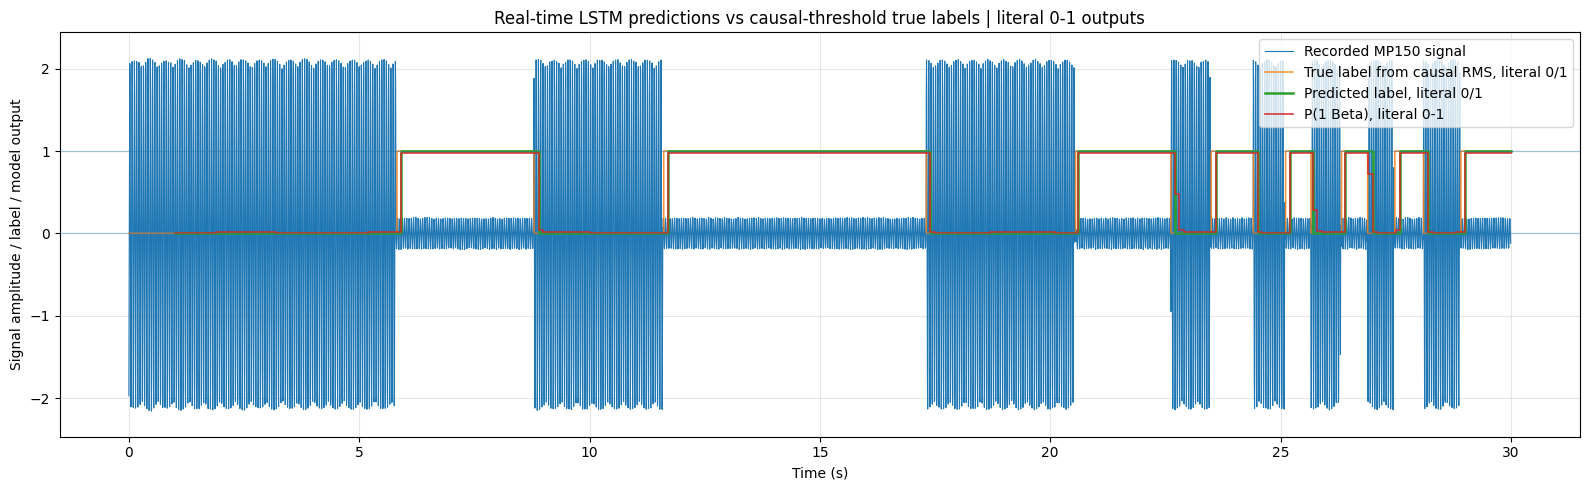

In [ ]:

import matplotlib.pyplot as plt


def _get_overlay_axis_limits(signal, include_unit_range=True, percentiles=(1.0, 99.0), pad_fraction=0.08):
    """Return robust y-limits that include the raw signal and the model-output range 0-1."""
    signal = np.asarray(signal, dtype=np.float64).reshape(-1)
    finite = signal[np.isfinite(signal)]

    if finite.size == 0:
        y_low, y_high = 0.0, 1.0
    else:
        p_low, p_high = percentiles
        y_low, y_high = np.percentile(finite, [float(p_low), float(p_high)])

        if not np.isfinite(y_low) or not np.isfinite(y_high) or y_low == y_high:
            y_low = float(np.nanmin(finite))
            y_high = float(np.nanmax(finite))

        if y_low == y_high:
            span = max(abs(y_low), 1.0)
            y_low -= 0.5 * span
            y_high += 0.5 * span

    if include_unit_range:
        y_low = min(float(y_low), 0.0)
        y_high = max(float(y_high), 1.0)

    span = y_high - y_low
    if span <= 0 or not np.isfinite(span):
        y_low, y_high = -0.1, 1.1
        span = y_high - y_low

    pad = float(pad_fraction) * span
    return y_low - pad, y_high + pad


def _prediction_step_arrays(predictions, signal_end_time_sec):
    """Return step-plot arrays for prediction rows."""
    if len(predictions) == 0:
        return np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)

    t_pred = predictions['end_time_sec'].to_numpy(dtype=float)
    y_pred = predictions['pred_label'].to_numpy(dtype=float)

    if 'prob_beta' in predictions.columns:
        p_beta = predictions['prob_beta'].to_numpy(dtype=float)
    else:
        p_beta = np.full_like(y_pred, np.nan, dtype=float)

    if t_pred.size > 0 and np.isfinite(signal_end_time_sec) and signal_end_time_sec > t_pred[-1]:
        t_pred_plot = np.r_[t_pred, signal_end_time_sec]
        y_pred_plot = np.r_[y_pred, y_pred[-1]]
        p_beta_plot = np.r_[p_beta, p_beta[-1]]
    else:
        t_pred_plot = t_pred
        y_pred_plot = y_pred
        p_beta_plot = p_beta

    return t_pred_plot, y_pred_plot, p_beta_plot


def _load_true_labels_for_plot(true_labels_npz, max_duration_sec=None):
    """Load true-label arrays saved by run_prediction_evaluation()."""
    true_labels_npz = Path(true_labels_npz)
    if not true_labels_npz.exists():
        return None
    labeled = np.load(true_labels_npz, allow_pickle=True)
    labels = np.asarray(labeled['sample_labels'], dtype=np.float32).reshape(-1)
    label_signal = np.asarray(labeled['label_signal'], dtype=np.float64).reshape(-1)
    fs = int(np.asarray(labeled['samplerate']).item())
    t = np.arange(len(labels), dtype=np.float64) / float(fs)

    if max_duration_sec is not None:
        keep = t <= float(max_duration_sec)
        t = t[keep]
        labels = labels[keep]
        label_signal = label_signal[keep]

    return {
        'time_sec': t,
        'sample_labels': labels,
        'label_signal': label_signal,
        'threshold': float(np.asarray(labeled['threshold']).item()),
        'rolling_rms_sec': float(np.asarray(labeled['rolling_rms_sec']).item()),
        'signal_key': str(np.asarray(labeled['signal_key']).item()) if 'signal_key' in labeled.files else '',
    }


def plot_realtime_prediction_overlay(
    prediction_csv=None,
    recorded_npz=RECORDED_SIGNAL_NPZ,
    true_labels_npz=TRUE_LABELS_NPZ,
    output_png=OVERLAY_PNG,
    signal_key=PLOT_SIGNAL_KEY,
    max_duration_sec=PLOT_MAX_DURATION_SEC,
    signal_percentiles=PLOT_SIGNAL_PERCENTILES,
    show_true_label=PLOT_SHOW_TRUE_LABEL,
    show_true_label_signal=PLOT_SHOW_TRUE_LABEL_SIGNAL,
):
    """Plot recorded MP150 signal, true labels, and model outputs on the exact same axis.

    Important: labels/model outputs are NOT scaled to the signal amplitude.

    - raw/model-input signal: native MP150 amplitude units
    - true label: exactly 0 or 1
    - predicted label: exactly 0 or 1
    - P(1 Beta): continuous value in [0, 1]
    """
    recorded_npz = Path(recorded_npz)
    output_png = Path(output_png) if output_png is not None else None

    if prediction_csv is None:
        prediction_csv = EVALUATED_PREDICTION_CSV if Path(EVALUATED_PREDICTION_CSV).exists() else PREDICTION_CSV
    prediction_csv = Path(prediction_csv)

    if not prediction_csv.exists():
        raise FileNotFoundError(f'Prediction CSV not found: {prediction_csv}')
    if not recorded_npz.exists():
        raise FileNotFoundError(f'Recorded signal NPZ not found: {recorded_npz}')

    predictions = pd.read_csv(prediction_csv)
    recorded = np.load(recorded_npz, allow_pickle=True)

    available_signal_keys = {'raw_signal', 'model_input_signal'}
    if signal_key not in available_signal_keys:
        raise ValueError(f'signal_key must be one of {sorted(available_signal_keys)}, got {signal_key!r}.')
    if signal_key not in recorded.files:
        raise KeyError(f'{signal_key!r} not found in {recorded_npz}. Found keys: {recorded.files}')

    signal = np.asarray(recorded[signal_key], dtype=np.float32).reshape(-1)
    samplerate = int(np.asarray(recorded['samplerate']).item())
    t_signal = np.arange(len(signal), dtype=np.float64) / float(samplerate)

    if max_duration_sec is not None:
        max_duration_sec = float(max_duration_sec)
        keep_signal = t_signal <= max_duration_sec
        t_signal = t_signal[keep_signal]
        signal = signal[keep_signal]
        if len(predictions) > 0 and 'end_time_sec' in predictions.columns:
            predictions = predictions[predictions['end_time_sec'] <= max_duration_sec].copy()

    signal_end_time_sec = float(t_signal[-1]) if len(t_signal) else 0.0
    t_pred_plot, y_pred_plot, p_beta_plot = _prediction_step_arrays(predictions, signal_end_time_sec)
    true_plot = _load_true_labels_for_plot(true_labels_npz, max_duration_sec=max_duration_sec) if show_true_label or show_true_label_signal else None

    signal_label = 'Recorded MP150 signal'
    if signal_key == 'model_input_signal':
        signal_label = 'Model-input signal after online calibration'

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(t_signal, signal, linewidth=0.8, label=signal_label)

    if true_plot is not None and show_true_label_signal:
        ax.plot(
            true_plot['time_sec'],
            true_plot['label_signal'],
            linewidth=0.8,
            alpha=0.7,
            label=f"Causal RMS true-label signal ({true_plot['rolling_rms_sec']:.3f}s)",
        )
        ax.axhline(true_plot['threshold'], linewidth=0.9, linestyle='--', alpha=0.5, label=f"True-label threshold={true_plot['threshold']:.3f}")

    if true_plot is not None and show_true_label:
        ax.step(
            true_plot['time_sec'],
            true_plot['sample_labels'],
            where='post',
            linewidth=1.1,
            alpha=0.85,
            label='True label from causal RMS, literal 0/1',
        )

    if len(predictions) > 0:
        ax.step(
            t_pred_plot,
            y_pred_plot,
            where='post',
            linewidth=1.8,
            label='Predicted label, literal 0/1',
        )

        if np.any(np.isfinite(p_beta_plot)):
            ax.step(
                t_pred_plot,
                p_beta_plot,
                where='post',
                linewidth=1.2,
                alpha=0.9,
                label='P(1 Beta), literal 0-1',
            )

        ax.axhline(0.0, linewidth=0.9, alpha=0.35)
        ax.axhline(1.0, linewidth=0.9, alpha=0.35)
    else:
        ax.text(0.5, 0.5, 'No predictions were logged.', transform=ax.transAxes, ha='center', va='center')

    y_min, y_max = _get_overlay_axis_limits(signal, include_unit_range=True, percentiles=signal_percentiles)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Signal amplitude / label / model output')
    ax.grid(True, alpha=0.3)

    title = 'Real-time LSTM predictions vs causal-threshold true labels | literal 0-1 outputs'
    if max_duration_sec is not None:
        title += f' | first {max_duration_sec:g} s'
    ax.set_title(title)
    ax.legend(loc='upper right')
    plt.tight_layout()

    if output_png is not None:
        output_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_png, dpi=150, bbox_inches='tight')
        print(f'Saved prediction plot to: {output_png}')

    plt.show()
    return fig, ax


# Create the final plot after acquisition and evaluation have completed.
fig, ax = plot_realtime_prediction_overlay()
